# Stage 1 — Dataset and understanding

**Industrial AI-based predictive maintenance and process fault detection**

Before any modelling: what is this data, what does every column physically
mean, and what counts as normal versus abnormal operation?

## The dataset

The **AI4I 2020 Predictive Maintenance Dataset** (UCI Machine Learning
Repository) records 10,000 production cycles of a milling machine. It is
synthetic but built to mirror real industrial predictive-maintenance data, and
it is the standard public benchmark for this problem because real plant data is
almost never shareable.

Each row is one machining cycle: a snapshot of six measurements plus the
outcome of that cycle.

## What each column physically means

| Column | Meaning | Why it matters |
|---|---|---|
| `Type` | Machine quality variant: L / M / H | Cheaper variants tolerate less abuse before failing |
| `Air temperature [K]` | Ambient shop-floor temperature | The heat sink the process rejects heat into |
| `Process temperature [K]` | Temperature at the cutting zone | Rises with cutting energy; always above ambient |
| `Rotational speed [rpm]` | Spindle speed | Together with torque, sets delivered power |
| `Torque [Nm]` | Torque at the spindle | The load being carried |
| `Tool wear [min]` | Cumulative minutes the current tool has cut | The degradation clock |
| `Machine failure` | Did this cycle end in a stoppage | The binary target |
| `TWF HDF PWF OSF RNF` | Which failure mode was recorded | The diagnostic target |

## Normal vs abnormal operation

A cycle is *normal* when the spindle delivers power inside its design band, the
process can reject its heat into ambient air, and the tool has cutting life
left. Abnormal operation is any of those breaking down — and the dataset names
five distinct ways it happens:

- **TWF** — tool wear failure: the tool is worn out
- **HDF** — heat dissipation failure: the process cannot shed its heat
- **PWF** — power failure: delivered power is outside the workable band
- **OSF** — overstrain failure: accumulated load exceeds what the variant takes
- **RNF** — random failure: a failure with *no* physical cause in the sensors


In [1]:
import sys, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg, data, features, eda, models, evaluate, anomaly, explain, viz
viz.apply_style()
pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)


In [2]:
df_raw = data.load_raw()
print(f"{df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head()

10,000 rows x 14 columns


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Schema and completeness

The first thing to establish is whether the data needs cleaning at all.


In [3]:
schema = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "non_null": df_raw.notna().sum(),
    "missing": df_raw.isna().sum(),
    "unique": df_raw.nunique(),
})
schema

,dtype,non_null,missing,unique
UDI,int64,10000,0,10000
Product ID,str,10000,0,10000
Type,str,10000,0,3
Air temperature [K],float64,10000,0,93
Process temperature [K],float64,10000,0,82
Rotational speed [rpm],int64,10000,0,941
Torque [Nm],float64,10000,0,577
Tool wear [min],int64,10000,0,246
Machine failure,int64,10000,0,2
TWF,int64,10000,0,2


In [4]:
print("total missing values:", int(df_raw.isna().sum().sum()))
print("duplicate UDI values:", int(df_raw[cfg.COL_UDI].duplicated().sum()))
print("duplicate full rows :", int(df_raw.duplicated().sum()))
print()
df_raw[cfg.SENSOR_COLS].describe().T

total missing values: 0
duplicate UDI values: 0
duplicate full rows : 0



,count,mean,std,min,25%,50%,75%,max
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.0,108.0,162.0,253.0


The data is complete: no missing values, no duplicate rows, no duplicate
identifiers. That is unusual for real plant data and worth naming explicitly —
the cleaning effort here goes into *label* consistency, not into missing values.

`UDI` and `Product ID` are identifiers, not features. `UDI` is a row counter,
and `Product ID` just encodes the machine type that is already a column.
Feeding either one to a model would leak row ordering.

## Label integrity — where the real work is

The published failure counts are easy to take at face value. They contain three
inconsistencies that determine what the models can and cannot achieve.


In [5]:
audit = data.audit_labels(df_raw)
for k, v in audit.as_dict().items():
    print(f"{k:32s} {v}")

n_rows                           10000
n_missing                        0
n_duplicate_ids                  0
n_failures                       339
failure_rate                     0.0339
mode_counts                      {'TWF': 46, 'HDF': 115, 'PWF': 95, 'OSF': 98, 'RNF': 19}
n_failure_no_mode                9
n_mode_without_failure           0
n_multi_mode                     23
multi_mode_combos                {'PWF+OSF': 11, 'HDF+OSF': 6, 'HDF+PWF': 3, 'TWF+OSF': 2, 'TWF+PWF+OSF': 1}
n_rnf_flagged                    19
n_rnf_and_failure                1


Three findings, each with a modelling consequence:

**1. `RNF` is almost decorative.** Nineteen rows are flagged as random
failures, but only **one** of them is also flagged `Machine failure`. The other
eighteen are random-failure flags on cycles that completed fine. RNF therefore
stays in the binary target (a failure is a failure operationally) but is
excluded from the fault-mode classifier — by construction it has no sensor
signature, so it would be an unlearnable class dragging down macro metrics for
reasons unrelated to model quality.

**2. Nine failures have no mode flag at all.** A stoppage was recorded, but no
cause. These rows remain in the binary problem and are excluded from the
fault-mode problem.

**3. Twenty-three failures carry two or more modes simultaneously.** Most
commonly power together with overstrain — physically sensible, since a spindle
being overloaded is both drawing abnormal power and accumulating strain. This
makes fault diagnosis a **multi-label** problem, not a multi-class one.


In [6]:
noise = data.label_noise_floor(df_raw)
for k, v in noise.items():
    print(f"{k:34s} {v}")

print()
print(f"=> {noise['n_unexplained_failures']} of {noise['n_failures']} failures "
      f"({noise['unexplained_share_of_failures']:.1%}) have no physical signature.")
print("   No sensor-driven model can predict these. This is the noise floor:")
print("   it caps achievable recall and is not a defect in the model.")

n_failures                         339
n_unexplained_failures             9
unexplained_share_of_failures      0.02654867256637168
n_explainable_failures             330

=> 9 of 339 failures (2.7%) have no physical signature.
   No sensor-driven model can predict these. This is the noise floor:
   it caps achievable recall and is not a defect in the model.


## Failure mode distribution


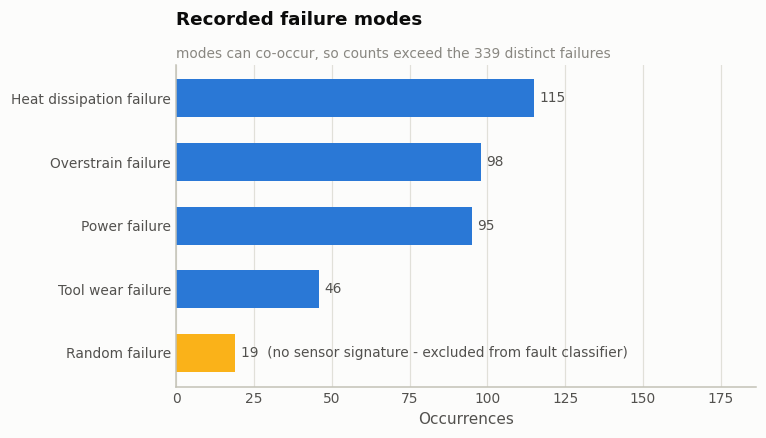

In [7]:
df = data.add_targets(df_raw)
df = features.add_physics_features(df)
ax = eda.plot_mode_counts(df)
plt.show()

In [8]:
combos = (df.loc[df.mode_eligible, cfg.MODE_COLS_MODELLED]
            .apply(lambda r: "+".join(m for m in cfg.MODE_COLS_MODELLED if r[m] == 1), axis=1)
            .value_counts())
print("Mode signatures among failures with a physical cause:\n")
print(combos.to_string())

Mode signatures among failures with a physical cause:

HDF            106
PWF             80
OSF             78
TWF             43
PWF+OSF         11
HDF+OSF          6
HDF+PWF          3
TWF+OSF          2
TWF+PWF+OSF      1


## What Stage 1 established

- 10,000 clean rows, no missing values, no imputation needed
- A **3.39% failure rate** — accuracy is useless as a metric here
- A **2.7% label noise floor** among failures that caps recall
- Fault diagnosis is **multi-label**, conditional on a failure occurring
- `UDI` and `Product ID` are excluded as identifiers

Next: Stage 2 turns the six raw measurements into the physical quantities that
actually govern whether this machine survives a cycle.
